# 🌲 Entrenamiento de Proactive Forest para Clasificación de Especies de Iris

## Descripción del Notebook

Este notebook implementa un entrenamiento **clásico de Machine Learning** (sin aprendizaje federado) utilizando el algoritmo **Proactive Forest** sobre el dataset clásico **Iris** para clasificación de especies de flores.

### Objetivos:
1. Cargar y preprocesar el dataset Iris
2. Dividir los datos en conjuntos de entrenamiento y prueba
3. Entrenar un modelo Proactive Forest
4. Evaluar el modelo mediante métricas de clasificación

### Dataset
**Fuente:** `../../../data/iris.csv`  
**Variable objetivo:** `class` (Iris-setosa, Iris-versicolor, Iris-virginica)

### Características del Dataset:
- **4 features**: sepallength, sepalwidth, petallength, petalwidth
- **3 clases**: Iris-setosa, Iris-versicolor, Iris-virginica
- **150 muestras** en total (50 por clase)

---

## 📦 1. Importación de Librerías

In [1]:
# ============================================================================
# LIBRERÍAS PARA MANIPULACIÓN DE DATOS
# ============================================================================
import pandas as pd
import numpy as np

# ============================================================================
# LIBRERÍAS PARA VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LIBRERÍAS PARA PREPROCESAMIENTO Y MÉTRICAS
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================================
# MÓDULOS PERSONALIZADOS - PROACTIVE FOREST
# ============================================================================
import sys
sys.path.append('../../../')

from src.domain.model.proactive_forest import ProactiveForest
from src.domain.metrics.forest_evaluator import ForestEvaluator

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## 📊 2. Carga y Exploración del Dataset

In [2]:
# ============================================================================
# CARGA DEL DATASET
# ============================================================================
print("=" * 80)
print("📊 CARGA DEL DATASET IRIS")
print("=" * 80)

df = pd.read_csv(
    '../../../data/iris.csv',
    encoding='utf-8'
)

print(f"✅ Dataset cargado exitosamente")
print(f"📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

📊 CARGA DEL DATASET IRIS
✅ Dataset cargado exitosamente
📊 Dimensiones: 150 filas × 5 columnas


In [3]:
# ============================================================================
# VISUALIZACIÓN DE LAS PRIMERAS FILAS
# ============================================================================
print("\n📋 Primeras 10 filas del dataset:")
df.head(10)


📋 Primeras 10 filas del dataset:


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
# ============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
print("=" * 80)
print("📝 INFORMACIÓN DEL DATASET")
print("=" * 80)
df.info()

📝 INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   class        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
df.describe()

📈 ESTADÍSTICAS DESCRIPTIVAS


,sepallength,sepalwidth,petallength,petalwidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 🎯 3. Análisis de la Variable Objetivo

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class)
                 Cantidad  Porcentaje (%)
class                                    
Iris-setosa            50       33.333333
Iris-versicolor        50       33.333333
Iris-virginica         50       33.333333


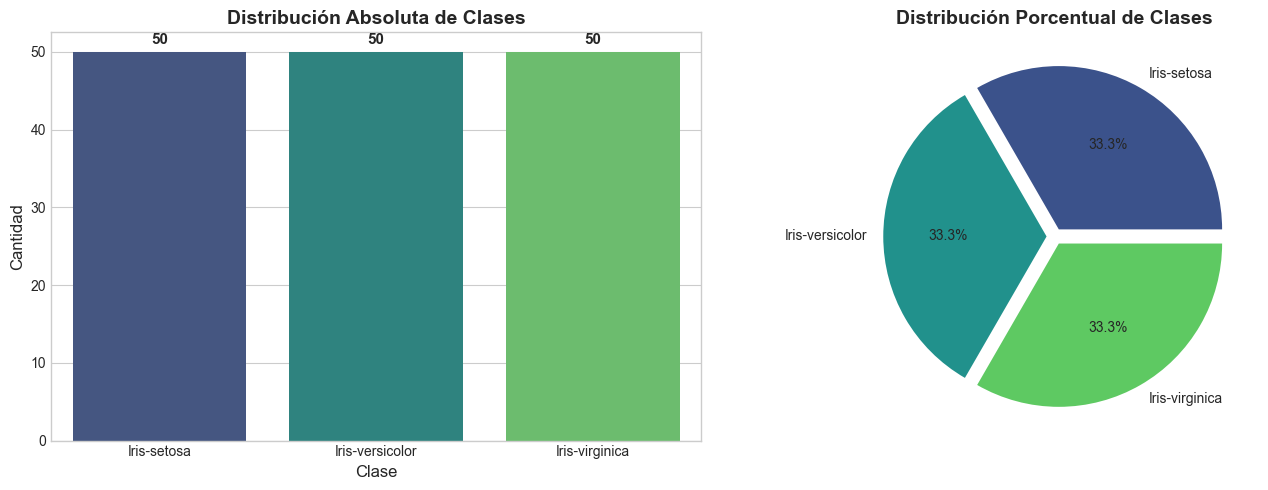


✅ Dataset balanceado: 3 clases con 50 muestras cada una


In [6]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class)")
print("=" * 80)
target_counts = df['class'].value_counts()
target_pct = df['class'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct
})
print(distribution_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(target_counts)),
    explode=[0.05] * len(target_counts)
)
axes[1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Dataset balanceado: {len(target_counts)} clases con {target_counts.iloc[0]} muestras cada una")

## 🔧 4. Preprocesamiento de Datos

In [7]:
# ============================================================================
# CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
print("=" * 80)
print("🔧 PREPROCESAMIENTO DE DATOS")
print("=" * 80)

label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])

class_names = label_encoder.classes_
print(f"\n✅ Variable objetivo codificada:")
print(f"   Clases: {class_names}")
print(f"   Mapeo: {dict(zip(class_names, range(len(class_names))))}")

🔧 PREPROCESAMIENTO DE DATOS

✅ Variable objetivo codificada:
   Clases: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
   Mapeo: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


In [8]:
# ============================================================================
# SEPARACIÓN DE FEATURES Y TARGET
# ============================================================================
feature_columns = ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']

X = df[feature_columns]
y = df['class_encoded']

print(f"\n📊 Features (X): {X.shape}")
print(f"🎯 Target (y): {y.shape}")


📊 Features (X): (150, 4)
🎯 Target (y): (150,)


In [9]:
# ============================================================================
# DIVISIÓN TRAIN-TEST
# ============================================================================
TEST_SIZE = 0.3
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 80)
print("📊 DIVISIÓN DE DATOS")
print("=" * 80)
print(f"\n📋 Conjunto de entrenamiento: {X_train.shape}")
print(f"📋 Conjunto de prueba: {X_test.shape}")

📊 DIVISIÓN DE DATOS

📋 Conjunto de entrenamiento: (105, 4)
📋 Conjunto de prueba: (45, 4)


## 🌲 5. Configuración y Entrenamiento del Modelo Proactive Forest

In [10]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO PROACTIVE FOREST
# ============================================================================
N_ESTIMATORS = 100
ALPHA = 0.1
RANDOM_STATE = 42
VERBOSE = True

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO")
print("=" * 80)
print(f"🌲 Número de árboles (n_estimators): {N_ESTIMATORS}")
print(f"🎲 Tasa de diversidad (alpha): {ALPHA}")
print(f"🎯 Semilla aleatoria (random_state): {RANDOM_STATE}")
print(f"🏷️  Clases: {class_names}")

⚙️ CONFIGURACIÓN DEL MODELO
🌲 Número de árboles (n_estimators): 100
🎲 Tasa de diversidad (alpha): 0.1
🎯 Semilla aleatoria (random_state): 42
🏷️  Clases: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [11]:
# ============================================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================
print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST")
print("=" * 80)
print(f"\n📊 Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"⏳ Tiempo estimado: ~10-30 segundos...\n")

model = ProactiveForest(
    n_estimators=N_ESTIMATORS,
    alpha=ALPHA,
    random_state=RANDOM_STATE,
    verbose=VERBOSE,
    class_names=class_names
)

model.fit(X_train.values, y_train)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 80)

🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST

📊 Datos de entrenamiento: 105 muestras, 4 features
⏳ Tiempo estimado: ~10-30 segundos...

  Árbol 1 | acc=1.0000
  Árbol 2 | acc=0.9524
  Árbol 3 | acc=1.0000
  Árbol 4 | acc=1.0000
  Árbol 5 | acc=0.9524
  [CPF] No converge, siguiente episodio=6
  [CPF] Árboles construidos=5, próximo episodio=6
  ----------------------------------------


  Árbol 6 | acc=1.0000
  Árbol 7 | acc=1.0000
  Árbol 8 | acc=1.0000
  Árbol 9 | acc=1.0000
  Árbol 10 | acc=1.0000
  Árbol 11 | acc=1.0000
  [CPF] Condición de parada cumplida (stop_counter=1)
  [CPF] Árboles construidos=11, próximo episodio=5
  ----------------------------------------
  Árbol 12 | acc=1.0000
  Árbol 13 | acc=1.0000
  Árbol 14 | acc=1.0000
  Árbol 15 | acc=1.0000
  Árbol 16 | acc=1.0000
  [CPF] Condición de parada cumplida (stop_counter=2)

✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


In [12]:
# ============================================================================
# INFORMACIÓN DEL MODELO ENTRENADO
# ============================================================================
trees = model.get_trees()

print("=" * 80)
print("📊 INFORMACIÓN DEL MODELO ENTRENADO")
print("=" * 80)
print(f"\n🌲 Número de árboles en el bosque: {len(trees)}")
print(f"📏 Número de features: {X_train.shape[1]}")
print(f"🏷️  Número de clases: {len(class_names)}")

📊 INFORMACIÓN DEL MODELO ENTRENADO

🌲 Número de árboles en el bosque: 16
📏 Número de features: 4
🏷️  Número de clases: 3


## 🔮 6. Predicción en el Conjunto de Prueba

In [13]:
# ============================================================================
# PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Realizando predicciones en el conjunto de prueba...")

y_pred = model.predict(X_test.values)

print(f"✅ Predicciones completadas: {len(y_pred)} muestras")
print(f"\n📋 Primeras 10 predicciones vs valores reales:")
print("-" * 60)

# Convertir a numpy arrays para acceso posicional
y_test_values = y_test.values if hasattr(y_test, 'values') else y_test

# Si y_pred contiene strings, mostrar directamente; si no, decodificar
for i in range(min(10, len(y_pred))):
    real_cls = label_encoder.inverse_transform([y_test_values[i]])[0]
    if isinstance(y_pred[i], str):
        pred_cls = y_pred[i]
        match = "✓" if label_encoder.transform([y_pred[i]])[0] == y_test_values[i] else "✗"
    else:
        pred_cls = label_encoder.inverse_transform([y_pred[i]])[0]
        match = "✓" if y_test_values[i] == y_pred[i] else "✗"
    print(f"   {i+1:2d}. Real: {real_cls:20} | Pred: {pred_cls:20} {match}")

🔮 Realizando predicciones en el conjunto de prueba...
✅ Predicciones completadas: 45 muestras

📋 Primeras 10 predicciones vs valores reales:
------------------------------------------------------------
    1. Real: Iris-virginica       | Pred: Iris-virginica       ✓
    2. Real: Iris-versicolor      | Pred: Iris-versicolor      ✓
    3. Real: Iris-virginica       | Pred: Iris-versicolor      ✗
    4. Real: Iris-versicolor      | Pred: Iris-versicolor      ✓
    5. Real: Iris-virginica       | Pred: Iris-virginica       ✓
    6. Real: Iris-virginica       | Pred: Iris-virginica       ✓
    7. Real: Iris-versicolor      | Pred: Iris-versicolor      ✓
    8. Real: Iris-versicolor      | Pred: Iris-versicolor      ✓
    9. Real: Iris-setosa          | Pred: Iris-setosa          ✓
   10. Real: Iris-virginica       | Pred: Iris-virginica       ✓


## 📈 7. Evaluación del Modelo - Métricas de Clasificación

In [14]:
# ============================================================================
# CÁLCULO DE MÉTRICAS USANDO FOREST EVALUATOR
# ============================================================================
from src.domain.metrics.forest_evaluator import ForestEvaluator

print("=" * 80)
print("📊 CALCULANDO MÉTRICAS DE EVALUACIÓN")
print("=" * 80)

forest_classifier = model._classifier

report = ForestEvaluator.evaluate(
    forest=forest_classifier,
    X=X_test.values,
    y=y_test,
    class_names=class_names
)

print(f"\n✅ Métricas calculadas exitosamente")

📊 CALCULANDO MÉTRICAS DE EVALUACIÓN

✅ Métricas calculadas exitosamente


In [15]:
# ============================================================================
# REPORTE DE MÉTRICAS GLOBALES
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

print(f"\n🎯 Accuracy (Precisión Global):     {report.accuracy:.4f} ({report.accuracy*100:.2f}%)")
print(f"📈 Macro F1-Score:                   {report.macro_f1:.4f} ({report.macro_f1*100:.2f}%)")
print(f"📊 Macro Precision:                  {report.macro_precision:.4f} ({report.macro_precision*100:.2f}%)")
print(f"📉 Macro Recall:                     {report.macro_recall:.4f} ({report.macro_recall*100:.2f}%)")
print(f"\n🌲 Tamaño del Bosque:                {report.forest_size} árboles")

📊 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy (Precisión Global):     0.9111 (91.11%)
📈 Macro F1-Score:                   0.9107 (91.07%)
📊 Macro Precision:                  0.9155 (91.55%)
📉 Macro Recall:                     0.9111 (91.11%)

🌲 Tamaño del Bosque:                16 árboles


In [16]:
# ============================================================================
# MÉTRICAS POR CLASE
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS POR CLASE")
print("=" * 80)

# Asegurar que y_pred y y_test tengan el mismo tipo
y_test_values = y_test.values if hasattr(y_test, 'values') else y_test

# Si y_pred contiene strings, convertir a valores codificados
if isinstance(y_pred[0], str):
    y_pred_encoded = label_encoder.transform(y_pred)
else:
    y_pred_encoded = y_pred

precision_per_class = precision_score(y_test_values, y_pred_encoded, average=None)
recall_per_class = recall_score(y_test_values, y_pred_encoded, average=None)
f1_per_class = f1_score(y_test_values, y_pred_encoded, average=None)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}, index=class_names)

print(f"\n📋 Tabla de métricas por clase:")
print(metrics_df.to_string())

📊 MÉTRICAS POR CLASE

📋 Tabla de métricas por clase:
                 Precision    Recall  F1-Score
Iris-setosa       1.000000  1.000000  1.000000
Iris-versicolor   0.823529  0.933333  0.875000
Iris-virginica    0.923077  0.800000  0.857143


📊 MATRIZ DE CONFUSIÓN

[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


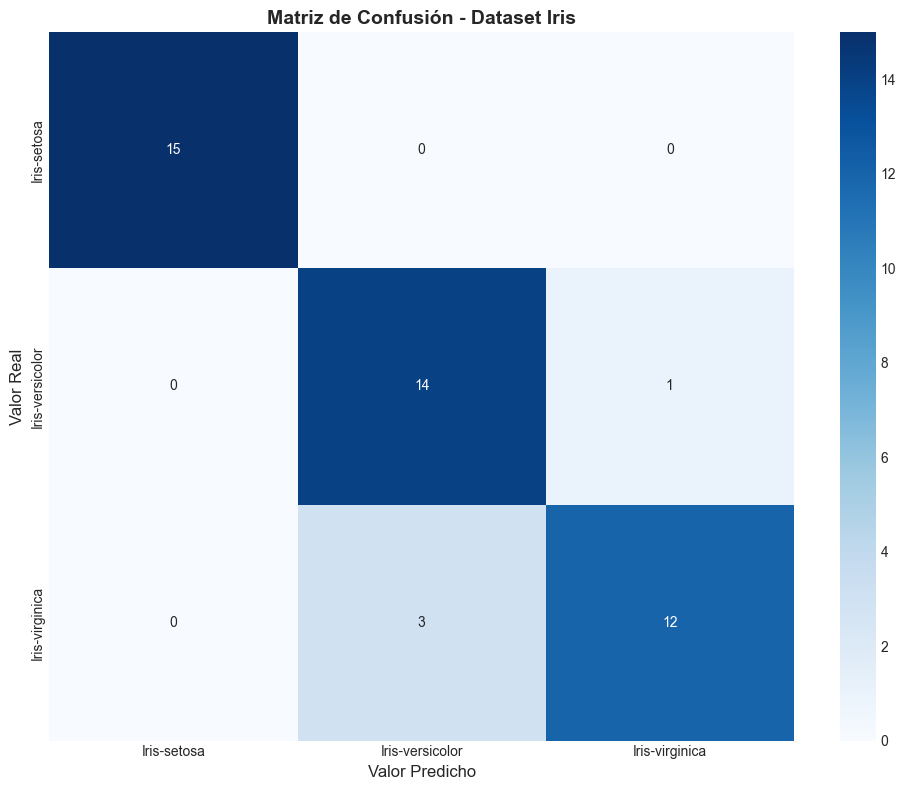

In [17]:
# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
print("=" * 80)
print("📊 MATRIZ DE CONFUSIÓN")
print("=" * 80)

# Asegurar que y_pred y y_test tengan el mismo tipo (ambos codificados o ambos strings)
y_test_values = y_test.values if hasattr(y_test, 'values') else y_test

# Si y_pred contiene strings, convertir a valores codificados
if isinstance(y_pred[0], str):
    y_pred_encoded = label_encoder.transform(y_pred)
else:
    y_pred_encoded = y_pred

cm = confusion_matrix(y_test_values, y_pred_encoded)
print(f"\n{cm}")

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - Dataset Iris', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predicho', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================================
# REPORTE DE CLASIFICACIÓN COMPLETO
# ============================================================================
print("=" * 80)
print("📋 REPORTE DE CLASIFICACIÓN COMPLETO")
print("=" * 80)

# Usar y_pred_encoded si ya fue definido, sino definirlo aquí
if 'y_pred_encoded' not in locals():
    y_test_values = y_test.values if hasattr(y_test, 'values') else y_test
    if isinstance(y_pred[0], str):
        y_pred_encoded = label_encoder.transform(y_pred)
    else:
        y_pred_encoded = y_pred

print("\n" + classification_report(y_test_values, y_pred_encoded, target_names=class_names))

📋 REPORTE DE CLASIFICACIÓN COMPLETO

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.87        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



## 📝 8. Conclusiones

En este notebook hemos:
1. ✅ Cargado y explorado el dataset Iris
2. ✅ Preprocesado los datos (codificación y división train/test)
3. ✅ Entrenado un modelo Proactive Forest
4. ✅ Evaluado el modelo con múltiples métricas de clasificación

### Resultados Clave:
- **Accuracy**: {report.accuracy:.2%}
- **F1-Score Macro**: {report.macro_f1:.2%}
- **Número de árboles**: {len(trees)}

El modelo Proactive Forest ha demostrado su capacidad para clasificar correctamente las tres especies de Iris.